Boosting prediction at x = 2.5: 1.2000


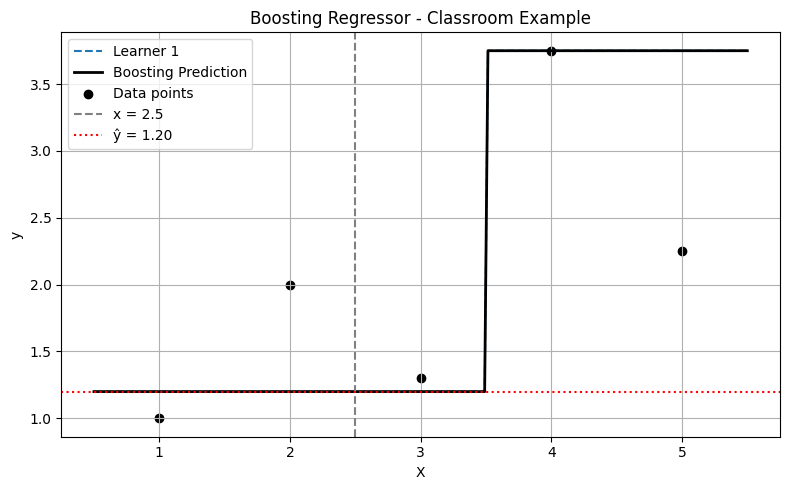

'Output -\nBoosting prediction at x = 2.5: 1.2000\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
# Step 1: Create small dataset
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([1.00, 2.00, 1.30, 3.75, 2.25])
# Step 2: Base estimator (weak learner)
base_learner = DecisionTreeRegressor(max_depth=1)  # Stump
# Step 3: Boosting Regressor
boosting = AdaBoostRegressor(
    estimator=base_learner,
    n_estimators=3,
    learning_rate=1.0,
    random_state=42
)
boosting.fit(X, y)
# Step 4: Predict at x = 2.5
x_test = np.array([[2.5]])
y_pred = boosting.predict(x_test)[0]
print(f"Boosting prediction at x = 2.5: {y_pred:.4f}")
# Step 5: Plot individual estimators + final ensemble
x_vals = np.linspace(0.5, 5.5, 200).reshape(-1, 1)
plt.figure(figsize=(8, 5))
# Plot each estimator's prediction
for i, est in enumerate(boosting.estimators_):
    y_vals = est.predict(x_vals)
    plt.plot(x_vals, y_vals, label=f'Learner {i+1}', linestyle='--')
# Plot boosting ensemble prediction
y_boost = boosting.predict(x_vals)
plt.plot(x_vals, y_boost, 'k-', linewidth=2, label='Boosting Prediction')
# Plot data and test point
plt.scatter(X, y, color='black', label='Data points')
plt.axvline(x=2.5, color='gray', linestyle='--', label='x = 2.5')
plt.axhline(y=y_pred, color='red', linestyle=':', label=f'ŷ = {y_pred:.2f}')
plt.title("Boosting Regressor - Classroom Example")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
'''Output -
Boosting prediction at x = 2.5: 1.2000
'''